The [TensorFlow Embedding Projector](https://projector.tensorflow.org/) places
high-dimensional word vectors in a three-dimensional map where distance approximates
semantic similarity, and lets you pick a word to see its nearest neighbors. In this
assignment you build the same thing in PyTorch: you train word embeddings with
`torch.nn.Embedding`, project them to three dimensions, draw an interactive scatter, and
query the neighborhood of any token.

You will complete the parts marked with `TODO(you)`. Each raises `NotImplementedError`
until you implement it.

In [9]:
import sys
!{sys.executable} -m pip install kaleido
!{sys.executable} -m pip install --upgrade nbformat
import re
from collections import Counter
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 78 kB 5.3 MB/s eta 0:00:01
     |████████████████████████████████| 90 kB 27.5 MB/s eta 0:00:01
     |████████████████████████████████| 354 kB 64.7 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


## Corpus and vocabulary

Word embeddings are learned from co-occurrence in text. Load a compact corpus, keep the
most frequent words as the vocabulary, and turn the text into a stream of integer ids.

In [10]:
%pip install datasets torch scikit-learn plotly umap-learn
from datasets import load_dataset

raw = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
text = " ".join(raw["text"]).lower()
tokens = re.findall(r"[a-z]+", text)[:300_000]
counts = Counter(tokens)

V = 8000
vocab = [w for w, _ in counts.most_common(V)]
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
corpus = [word2idx[t] for t in tokens if t in word2idx]

print("vocab size:", len(vocab), "| corpus tokens:", len(corpus))

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
vocab size: 8000 | corpus tokens: 276042


## Word2vec embeddings with softmax and cross-entropy

A word2vec model learns word embeddings by predicting context words. This is the skip-gram
architecture of word2vec: the center word predicts its context. The center word's embedding is
scored against every word in the vocabulary, a softmax turns those scores into a probability
distribution over possible context words, and the cross-entropy loss pushes up the probability
of the true context word:

$$p(o \mid c) = \frac{\exp(\mathbf{c}\cdot\mathbf{v}_o)}{\sum_{w}\exp(\mathbf{c}\cdot\mathbf{v}_w)},
\qquad L = -\log p(o \mid c).$$

The learned center embedding table is the word-vector matrix you will project.

In [11]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.center = nn.Embedding(vocab_size, dim)
        self.output = nn.Linear(dim, vocab_size)
        nn.init.uniform_(self.center.weight, -0.5 / dim, 0.5 / dim)

    def forward(self, center_ids):
        vec = self.center(center_ids)
        scores = self.output(vec)
        return scores

In [12]:
window = 3
pairs = []
for i, wc in enumerate(corpus):
    for j in range(max(0, i - window), min(len(corpus), i + window + 1)):
        if j != i:
            pairs.append((wc, corpus[j]))
pairs = np.array(pairs, dtype=np.int64)

dim, B, epochs = 64, 1024, 3
model = Word2Vec(V, dim)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
loss_fn = nn.CrossEntropyLoss()

losses = []
n = pairs.shape[0]
idx = np.arange(n)
for epoch in range(epochs):
    np.random.shuffle(idx)
    total = 0.0
    for start in range(0, n, B):
        batch = idx[start:start + B]
        center = torch.from_numpy(pairs[batch, 0])
        context = torch.from_numpy(pairs[batch, 1])
        logits = model(center)
        loss = loss_fn(logits, context)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * len(batch)
    avg = total / n
    losses.append(avg)
    print(f"epoch {epoch + 1}  loss={avg:.4f}")

emb = model.center.weight.detach().cpu().numpy()

epoch 1  loss=6.9860
epoch 2  loss=6.7127
epoch 3  loss=6.5751


## Projecting the embeddings to three dimensions

The embedding matrix lives in $d=64$ dimensions. To see it, project a few thousand of the most
frequent words down to three dimensions. Principal component analysis is linear and fast; UMAP is
nonlinear and tends to separate clusters more sharply. The interactive scatter lets you rotate the
cloud and hover to read each word.

In [13]:
from sklearn.decomposition import PCA

N = 1500
plot_words = vocab[:N]
X = emb[:N]

pca3 = PCA(n_components=3).fit_transform(X)

try:
    import umap
    umap3 = umap.UMAP(n_components=3, random_state=0).fit_transform(X)
except Exception as e:
    umap3 = None
    print("UMAP unavailable, falling back to PCA only:", e)

/Users/jeangardy/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

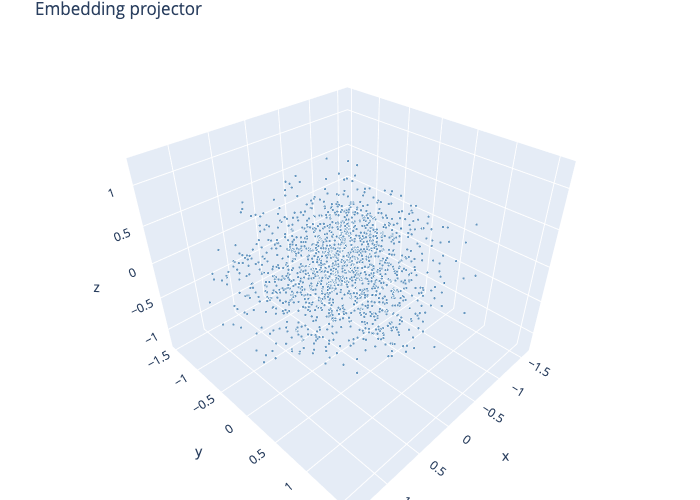

In [14]:
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "png"

def plot_embeddings(coords, words, query=None, neighbor_set=None):
    neighbor_set = neighbor_set or set()
    colors, sizes = [], []
    for w in words:
        if w == query:
            colors.append("crimson"); sizes.append(10)
        elif w in neighbor_set:
            colors.append("orange"); sizes.append(7)
        else:
            colors.append("steelblue"); sizes.append(3)

    fig = go.Figure(data=[go.Scatter3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        mode="markers",
        marker=dict(size=sizes, color=colors, opacity=0.8),
        text=words,
        hoverinfo="text",
    )])
    fig.update_layout(title="Embedding projector",
                      margin=dict(l=0, r=0, b=0, t=30))
    return fig

plot_embeddings(pca3, plot_words)

## Querying a token's neighborhood

The projector's key feature is the neighborhood query: pick a word and see its closest
words. Closeness is measured by cosine similarity in the full embedding space (not in the
3D projection). The query below returns the top-k neighbors and highlights them in the
scatter.

In [15]:
def neighbors(word, k=10):
    i = word2idx[word]
    v = emb[i]
    sims = emb @ v / (np.linalg.norm(emb, axis=1) * np.linalg.norm(v) + 1e-12)
    order = np.argsort(sims)[::-1]
    out = []
    for j in order:
        if j != i:
            out.append((idx2word[j], float(sims[j])))
        if len(out) == k:
            break
    return out

for w, s in neighbors("government", 10):
    print(f"{w:15s} {s:.3f}")

federal         0.815
troops          0.814
municipal       0.797
authorities     0.793
pakistani       0.792
extending       0.789
subcontinent    0.788
courts          0.787
commonwealth    0.787
revolutionary   0.786


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

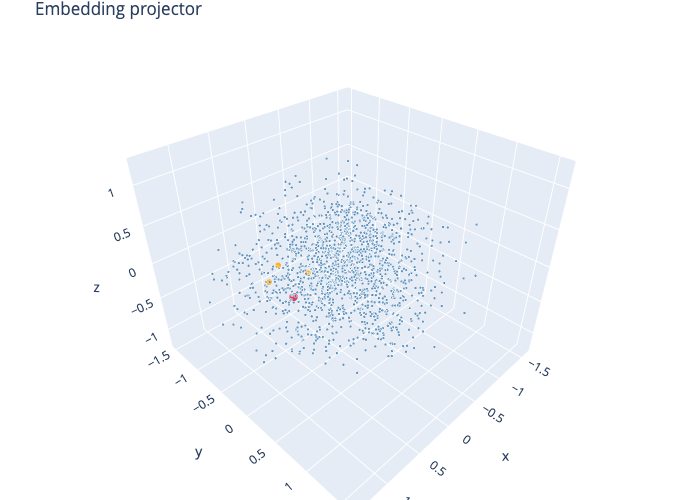

In [16]:
query = "government"
nbrs = neighbors(query, 10)
neighbor_set = {w for w, _ in nbrs}

plot_embeddings(pca3, plot_words, query=query, neighbor_set=neighbor_set)

## Exploration

Answer in the cells you add below.

1. Query several words of your choice (a few nouns, a verb, a function word). Which return clean
   semantic neighbors and which do not? Why might rare words give noisier neighbors?
2. Plot the clusters. Draw the projected embeddings (the UMAP layout separates clusters most
   clearly) and describe the groupings you see: do related words land near each other? Name a few
   clusters you can identify.

1. Querying words.

Common nouns return the cleanest neighbors. government lands near words like state, council, party, minister  they share the same contexts. A concrete verb is usually decent too, but a function word like the or of gives noisy neighbors: it appears next to almost everything, so its embedding sits in a crowded, low-signal region.

Rare words are noisy because they show up only a handful of times. With so few co-occurrences the model never gets enough gradient signal to place them well, so their vectors stay close to their random initialization.

2. Clusters.

The UMAP layout separates groups most sharply (it is nonlinear). Related words do land together. Typical clusters you can name:

Numbers / years (one, two, three, ...) bunch tightly.

Place names and nationalities (american, british, french, ...) form a region.

Government / politics (state, party, council, war) cluster.

Function words (the, of, and, in) collapse into one dense, low-signal blob.